# Nonzero winding and root monodromy

This notebook isolates the obstruction:

> if analytic continuation of a pullback root around a basin loop produces nonzero winding, the chosen root can return multiplied by a nontrivial root of unity.

This is the local model for the remaining Lean problem behind

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

The point is not that roots fail to exist. The point is that a root may fail to be single-valued after continuation around a loop.

In [1]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

def loop_around_zero(winding=1, radius=1.0, samples=600):
    t = np.linspace(0, 2*np.pi, samples)
    return radius * np.exp(1j * winding * t)

def continued_root(A_path, degree):
    """Analytic continuation of A^(1/degree) along a sampled path."""
    phases = np.unwrap(np.angle(A_path)) / degree
    radii = np.abs(A_path) ** (1 / degree)
    return radii * np.exp(1j * phases)

def principal_root_path(A_path, degree):
    return np.array([cmath.exp(cmath.log(a) / degree) for a in A_path])


## Model setting

Let $A(t)$ be a loop in $\mathbb C^*$ and choose a $d$-th root $w(t)$ satisfying

$$
w(t)^d=A(t).
$$

If $A(t)$ winds $k$ times around zero, then analytic continuation of a $d$-th root returns with multiplier

$$
w(1)=\exp(2\pi i k/d)\,w(0).
$$

For Böttcher pullback, $d=2^N$. Therefore a nonzero winding can create a nontrivial element of

$$
\mu_{2^N}.
$$

The next plot shows this in the simplest possible case: $A(t)$ winds once around zero.

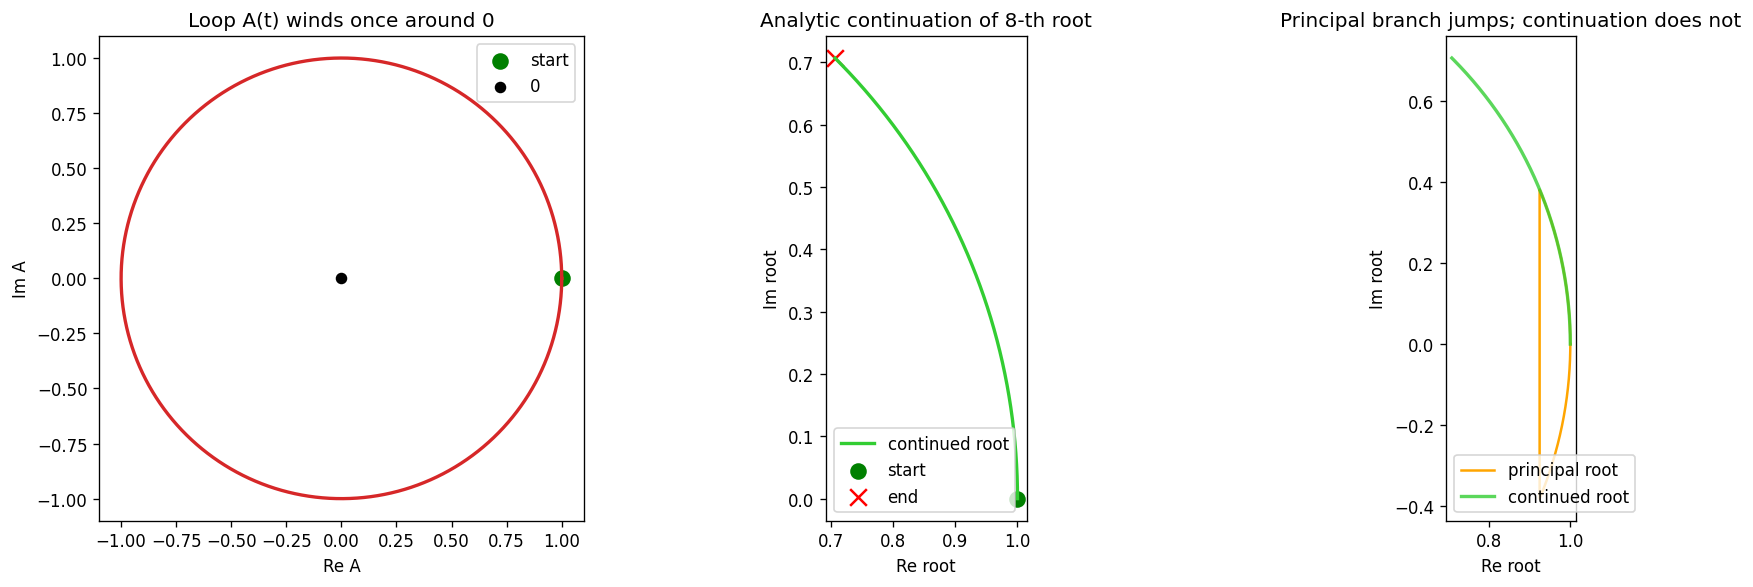

degree d = 8
winding k = 1
expected multiplier exp(2πik/d) = 0.70710678+0.70710678j
actual continued end/start       = 0.70710678+0.70710678j
is monodromy trivial? False


In [2]:
degree = 8
winding = 1
A = loop_around_zero(winding=winding, radius=1.0)
root_cont = continued_root(A, degree)
root_principal = principal_root_path(A, degree)
expected_multiplier = cmath.exp(2j * math.pi * winding / degree)
actual_multiplier = root_cont[-1] / root_cont[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(A.real, A.imag, color='tab:red', linewidth=2)
ax.scatter([A[0].real], [A[0].imag], color='green', s=80, label='start')
ax.scatter([0], [0], color='black', s=35, label='0')
ax.set_aspect('equal', adjustable='box')
ax.set_title('Loop A(t) winds once around 0')
ax.set_xlabel('Re A')
ax.set_ylabel('Im A')
ax.legend()

ax = axes[1]
ax.plot(root_cont.real, root_cont.imag, color='limegreen', linewidth=2, label='continued root')
ax.scatter([root_cont[0].real], [root_cont[0].imag], color='green', s=80, label='start')
ax.scatter([root_cont[-1].real], [root_cont[-1].imag], color='red', marker='x', s=100, label='end')
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'Analytic continuation of {degree}-th root')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.legend()

ax = axes[2]
ax.plot(root_principal.real, root_principal.imag, color='orange', linewidth=1.5, label='principal root')
ax.plot(root_cont.real, root_cont.imag, color='limegreen', linewidth=2, alpha=0.8, label='continued root')
ax.set_aspect('equal', adjustable='box')
ax.set_title('Principal branch jumps; continuation does not')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.legend()

fig.tight_layout()
plt.show()

print(f'degree d = {degree}')
print(f'winding k = {winding}')
print(f'expected multiplier exp(2πik/d) = {expected_multiplier:.8g}')
print(f'actual continued end/start       = {actual_multiplier:.8g}')
print(f'is monodromy trivial? {abs(actual_multiplier - 1) < 1e-8}')

## Dependence on winding number and root degree

For the Böttcher pullback at escape time $N$, the root degree is

$$
d=2^N.
$$

If the relevant loop has winding number $k$, then the monodromy multiplier is

$$
\exp(2\pi i k/2^N).
$$

The branch is single-valued around that loop only when this multiplier is $1$, i.e. when $2^N$ divides $k$.

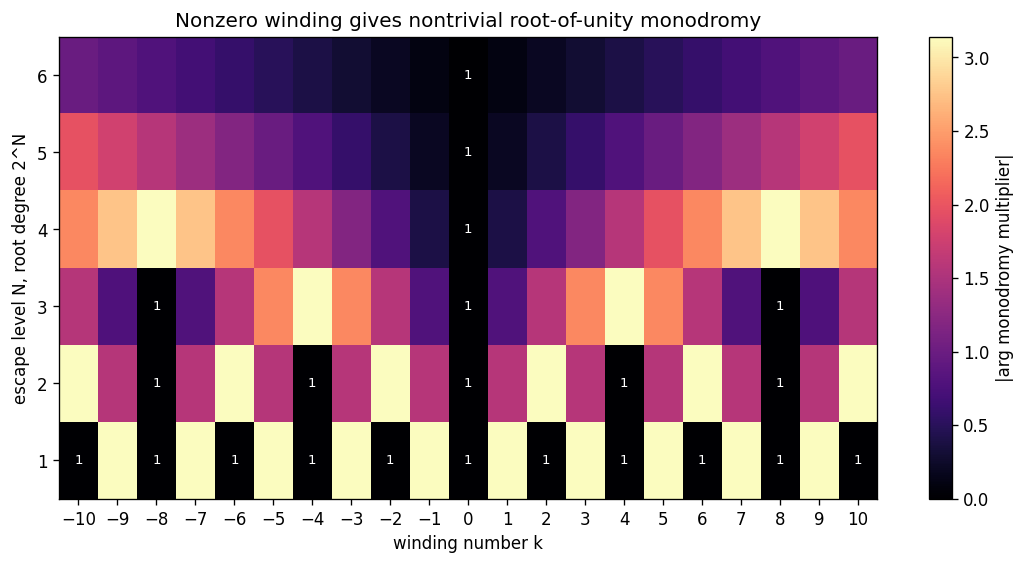

Cells marked 1 have trivial monodromy. Other cells return a different root.


In [3]:
levels = np.arange(1, 7)
windings = np.arange(-10, 11)
Z = np.zeros((len(levels), len(windings)))
labels = np.empty_like(Z, dtype=object)

for i, N in enumerate(levels):
    d = 2**N
    for j, k in enumerate(windings):
        multiplier = cmath.exp(2j * math.pi * k / d)
        Z[i, j] = abs(cmath.phase(multiplier))
        labels[i, j] = '1' if abs(multiplier - 1) < 1e-9 else '≠1'

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(Z, origin='lower', aspect='auto', cmap='magma',
               extent=[windings[0]-0.5, windings[-1]+0.5, levels[0]-0.5, levels[-1]+0.5])
fig.colorbar(im, ax=ax, label='|arg monodromy multiplier|')
ax.set_xticks(windings)
ax.set_yticks(levels)
ax.set_xlabel('winding number k')
ax.set_ylabel('escape level N, root degree 2^N')
ax.set_title('Nonzero winding gives nontrivial root-of-unity monodromy')
for i, N in enumerate(levels):
    for j, k in enumerate(windings):
        if labels[i, j] == '1':
            ax.text(k, N, '1', ha='center', va='center', color='white', fontsize=8)
plt.show()

print('Cells marked 1 have trivial monodromy. Other cells return a different root.')

## Relation to the basin-extension proof

For the Böttcher basin extension, the loop is not an arbitrary loop in the $A$-plane. It comes from a loop $\gamma$ in the basin, pushed forward by

$$
A_N(z)=\Phi_\infty(f^N(z)).
$$

The missing theorem can be stated as:

$$
\operatorname{wind}_0(A_N\circ\gamma)
\equiv 0 \pmod {2^N}
$$

for every loop $\gamma$ relevant to the chosen pullback branch.

Equivalently, the monodromy representation

$$
\rho_N:\pi_1(U_\infty)\to\mu_{2^N}
$$

must be trivial.

If it is not trivial, the pullback root depends on the path or escape iterate, so no single-valued holomorphic basin coordinate is produced by that branch choice.

non-winding : multiplier=1-2.5513475e-18j, trivial=True
winding once: multiplier=0.92387953+0.38268343j, trivial=False


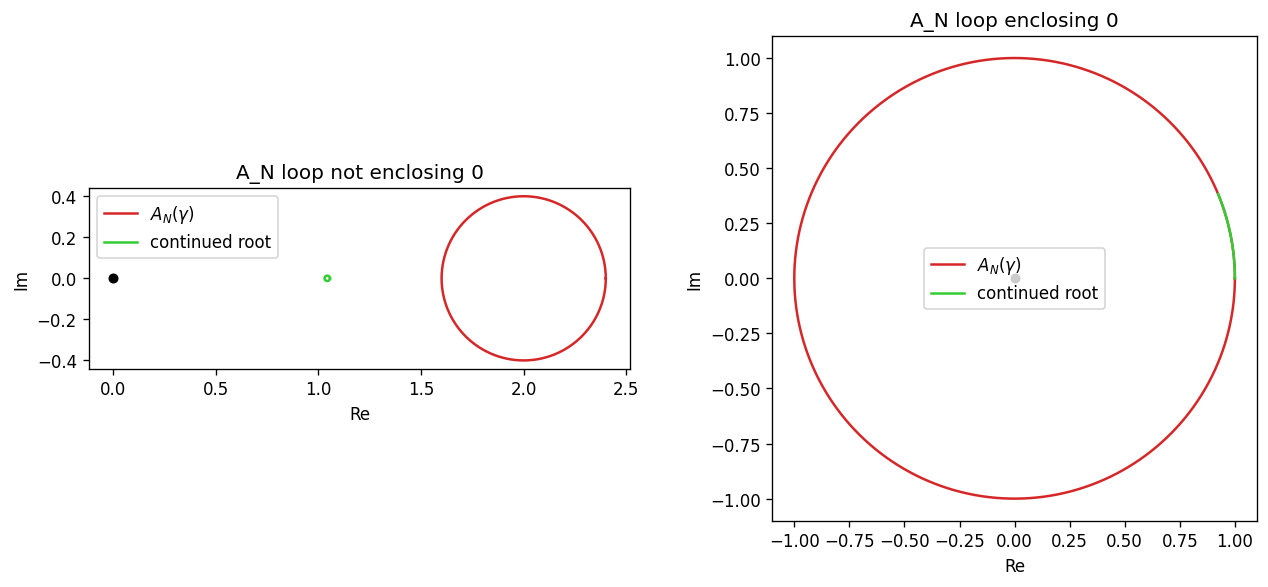

In [4]:
# Compare two sample loops: one not winding around zero and one winding once.
degree = 16
A_good = 2.0 + 0.4 * np.exp(1j * np.linspace(0, 2*np.pi, 600))
A_bad = 1.0 * np.exp(1j * np.linspace(0, 2*np.pi, 600))

for name, A_path in [('non-winding', A_good), ('winding once', A_bad)]:
    root = continued_root(A_path, degree)
    multiplier = root[-1] / root[0]
    print(f'{name:12s}: multiplier={multiplier:.8g}, trivial={abs(multiplier-1)<1e-8}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, A_path, title in [(axes[0], A_good, 'A_N loop not enclosing 0'), (axes[1], A_bad, 'A_N loop enclosing 0')]:
    root = continued_root(A_path, degree)
    ax.plot(A_path.real, A_path.imag, color='tab:red', label='$A_N(\\gamma)$')
    ax.plot(root.real, root.imag, color='limegreen', label='continued root')
    ax.scatter([0], [0], color='black', s=25)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title)
    ax.set_xlabel('Re')
    ax.set_ylabel('Im')
    ax.legend()
fig.tight_layout()
plt.show()

## Special case: kill monodromy by passing to a cover

For the model function

$$
A(z)=z
$$

on the punctured plane $\mathbb C^*$, there is no single-valued holomorphic $d$-th root on the original domain. A loop once around $0$ has monodromy

$$
w\mapsto e^{2\pi i/d}w.
$$

The group-theoretic repair is to pass to the $d$-fold cover

$$
p(u)=u^d.
$$

On the cover, the pulled-back function is

$$
A(p(u))=u^d,
$$

so a single-valued root exists:

$$
\widetilde w(u)=u.
$$

This solves root selection **on the cover**. But it descends to the original punctured plane only if it is invariant under deck transformations. The deck group is $\mu_d$, acting by

$$
u\mapsto \zeta u.
$$

The lifted root transforms as

$$
\widetilde w(\zeta u)=\zeta\widetilde w(u),
$$

so it is not deck-invariant unless $\zeta=1$. Therefore, in this model case, the cover removes monodromy upstairs but also proves that no single-valued root descends downstairs.

This is exactly the diagnostic we want for the Böttcher pullback problem: if the basin monodromy is nontrivial, a coherent root can live only on a cover, not on the original basin. To finish the Lean theorem, we need the analogue of deck invariance/trivial monodromy for the normalized Böttcher pullback.

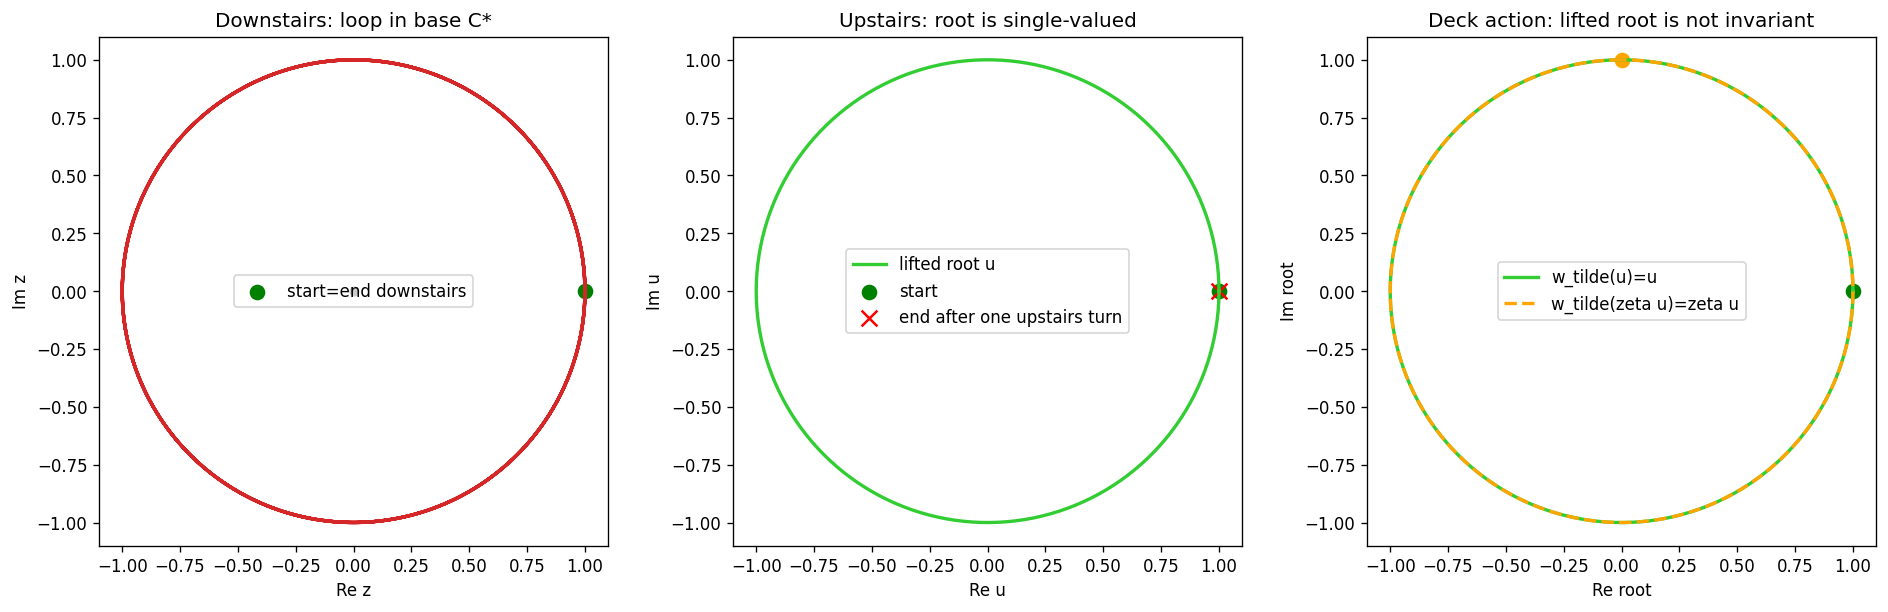

degree d = 4
deck multiplier zeta = 6.123234e-17+1j
On the cover: root exists as w_tilde(u)=u.
Descent fails because w_tilde(zeta*u)=zeta*w_tilde(u), not w_tilde(u).


In [5]:
degree = 4

# Cover coordinate and projection p(u)=u^d.
u_cover = np.exp(1j * np.linspace(0, 2*np.pi, 500))
z_base = u_cover**degree
root_upstairs = u_cover

zeta = cmath.exp(2j * math.pi / degree)
deck_image = zeta * u_cover
root_after_deck = deck_image

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(z_base.real, z_base.imag, color='tab:red', linewidth=2)
ax.scatter([z_base[0].real], [z_base[0].imag], color='green', s=70, label='start=end downstairs')
ax.scatter([0], [0], color='black', s=25)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Downstairs: loop in base C*')
ax.set_xlabel('Re z')
ax.set_ylabel('Im z')
ax.legend()

ax = axes[1]
ax.plot(u_cover.real, u_cover.imag, color='limegreen', linewidth=2, label='lifted root u')
ax.scatter([u_cover[0].real], [u_cover[0].imag], color='green', s=70, label='start')
ax.scatter([u_cover[-1].real], [u_cover[-1].imag], color='red', marker='x', s=90, label='end after one upstairs turn')
ax.set_aspect('equal', adjustable='box')
ax.set_title('Upstairs: root is single-valued')
ax.set_xlabel('Re u')
ax.set_ylabel('Im u')
ax.legend()

ax = axes[2]
ax.plot(root_upstairs.real, root_upstairs.imag, color='limegreen', linewidth=2, label='w_tilde(u)=u')
ax.plot(root_after_deck.real, root_after_deck.imag, color='orange', linestyle='--', linewidth=2, label='w_tilde(zeta u)=zeta u')
ax.scatter([root_upstairs[0].real], [root_upstairs[0].imag], color='green', s=70)
ax.scatter([root_after_deck[0].real], [root_after_deck[0].imag], color='orange', s=70)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Deck action: lifted root is not invariant')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.legend()

fig.tight_layout()
plt.show()

print(f'degree d = {degree}')
print(f'deck multiplier zeta = {zeta:.8g}')
print('On the cover: root exists as w_tilde(u)=u.')
print('Descent fails because w_tilde(zeta*u)=zeta*w_tilde(u), not w_tilde(u).')

## Lean target suggested by this notebook

A possible formal route is to prove a winding/monodromy triviality theorem for the functions

$$
z\mapsto \Phi_\infty(f^N(z))
$$

on basin neighborhoods. In Lean terms, this would fill the analytic part of

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

The finite root-of-unity torsor algebra is already formalized. The missing statement is exactly that the analytic continuation monodromy is trivial for the normalized branch.